In [11]:
# Importe de librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, Concatenate, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [12]:
# Carga del Dataset
metadata = pd.read_csv('HAM10000_metadata.csv')
img_data = pd.read_csv('hmnist_28_28_RGB.csv')

In [13]:
# Verificación de datos cargados
print(f"Forma de dataset de metadata: {metadata.shape}")
print(f"Forma de dataset de imágenes: {img_data.shape}")

Forma de dataset de metadata: (10015, 7)
Forma de dataset de imágenes: (10015, 2353)


In [14]:
# Información general de Metadata
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [15]:
# Información general Imagenes
img_data.info()
img_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Columns: 2353 entries, pixel0000 to label
dtypes: int64(2353)
memory usage: 179.8 MB


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [16]:
print(metadata.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


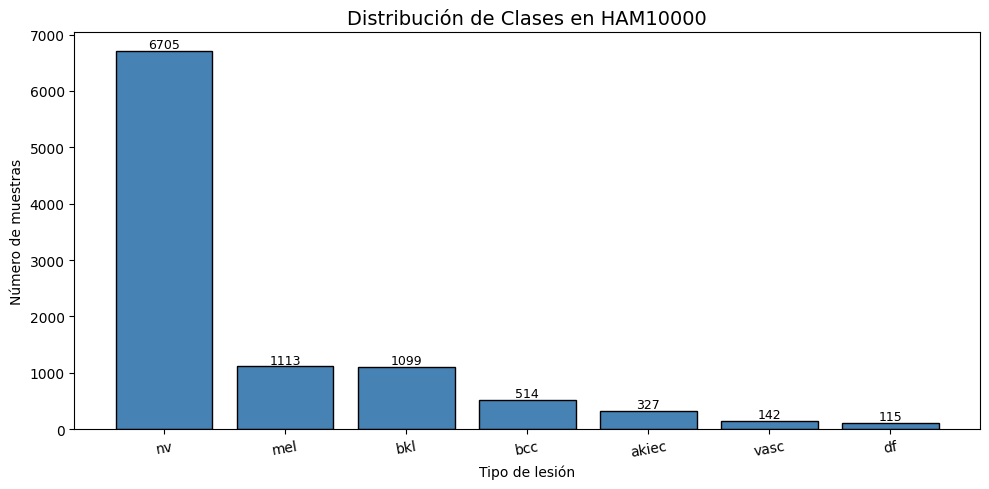

In [17]:
# Visualización de clases
plt.figure(figsize=(10, 5))
counts = metadata['dx'].value_counts()
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
plt.title('Distribución de Clases en HAM10000', fontsize=14)
plt.xlabel('Tipo de lesión')
plt.ylabel('Número de muestras')
plt.xticks(rotation=10)
for i, (cls, val) in enumerate(counts.items()):
    plt.text(i, val + 50, str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
# La clase nv parece estar con mayor frecuencia, por lo que puede generar mayor prediccion de esta clase.

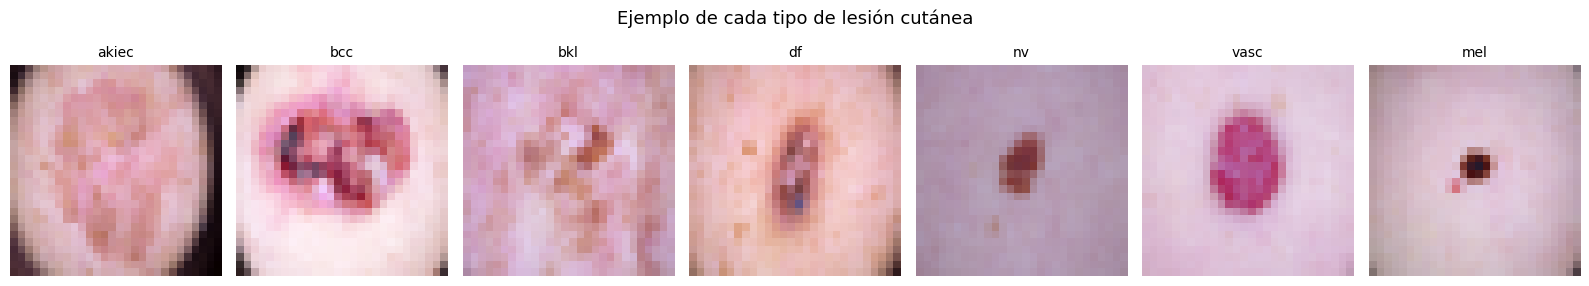

In [19]:
# Clasificación de cada imagen de la clases con sus respectivas etiquetas, solo por observación
label_map = {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'nv', 5: 'vasc', 6: 'mel'}
fig, axes = plt.subplots(1, 7, figsize=(16, 3))
for i in range(7):
    row = img_data[img_data['label'] == i].iloc[0]
    pixels = row.drop('label').values.astype(np.uint8)
    img = pixels.reshape(28, 28, 3)
    axes[i].imshow(img)
    axes[i].set_title(label_map[i], fontsize=10)
    axes[i].axis('off')
plt.suptitle('Ejemplo de cada tipo de lesión cutánea', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# MODELADO 1D TABULAR

In [ ]:
#PROCESAMIENTO DE DATOS

In [20]:
# 1. Uso de los datos unicamnete de sexo, edad, parte del cuerpo
#  Uso de copy para evitar la particion de metadata por warning
tab_df = metadata[['age', 'sex', 'localization']].copy()

In [21]:
print(tab_df)

        age     sex localization
0      80.0    male        scalp
1      80.0    male        scalp
2      80.0    male        scalp
3      80.0    male        scalp
4      75.0    male          ear
...     ...     ...          ...
10010  40.0    male      abdomen
10011  40.0    male      abdomen
10012  40.0    male      abdomen
10013  80.0    male         face
10014  70.0  female         back

[10015 rows x 3 columns]


In [22]:
# 2. 57 datos en la columna de Age son NULL. Se considera el uso de la Mediana para llenar estos datos
# Proceso tomado de: Hands-On Machine Learning" (Aurélien Géron)
mediana_edad = tab_df['age'].median()
tab_df['age'] = tab_df['age'].fillna(mediana_edad)

In [23]:
# 3. Normalizacion de datos
tab_df['age'] = tab_df['age'] / tab_df['age'].max()

In [24]:
# 4. Conversion de string a numeros (0, 1) de Sex y Localization
tab_df = pd.get_dummies(tab_df, columns=['sex', 'localization'])

In [25]:
X_tab = tab_df.values.astype(np.float32)

In [26]:
print(f"Features tabulares generadas: {tab_df.columns.tolist()}")
print(f"\nForma de los datos tabulares: {X_tab.shape}")

Features tabulares generadas: ['age', 'sex_female', 'sex_male', 'sex_unknown', 'localization_abdomen', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity']

Forma de los datos tabulares: (10015, 19)


In [27]:
print(X_tab)

[[0.9411765  0.         1.         ... 0.         0.         0.        ]
 [0.9411765  0.         1.         ... 0.         0.         0.        ]
 [0.9411765  0.         1.         ... 0.         0.         0.        ]
 ...
 [0.47058824 0.         1.         ... 0.         0.         0.        ]
 [0.9411765  0.         1.         ... 0.         0.         0.        ]
 [0.8235294  1.         0.         ... 0.         0.         0.        ]]


In [28]:
#PROCESAMIENTO DE IMAGENES

In [29]:
# Extracción de solo los pixeles de todas las columnas sin contar Label
X_img_tab = img_data.drop('label', axis=1).values.astype(np.float32)

In [30]:
# Normalización de pixeles (Van de 0 a 255)
X_img_tab = X_img_tab / 255

In [31]:
# Reshape de los datos de (10015, 2353) a (10015, 28, 28, 3)
X_img = tf.reshape(X_img_tab, shape=(-1, 28, 28, 3)).numpy()

In [32]:
X_img.shape

(10015, 28, 28, 3)

In [33]:
X_img.min()
X_img.max()

np.float32(1.0)

In [34]:
# Extraccion de etiquetas

In [35]:
y = img_data['label'].values

In [36]:
#One hot encoded para clasificacion de las clases
y_onehot = to_categorical(y, num_classes=7)

In [37]:
y_onehot.shape
y_onehot[y == 4][0]

array([0., 0., 0., 0., 1., 0., 0.])

In [38]:
# Division en train, validation, train
X_tab_tv, X_tab_test, X_img_tv, X_img_test, y_tv, y_test = train_test_split(
    X_tab, X_img, y_onehot,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
X_tab_train, X_tab_val, X_img_train, X_img_val, y_train, y_val = train_test_split(
    X_tab_tv, X_img_tv, y_tv,
    test_size=0.15,
    random_state=42,
    stratify=np.argmax(y_tv, axis=1)
)

In [40]:
#Verificacion de datos
X_tab_train.shape

(6810, 19)

In [41]:
X_tab_val.shape

(1202, 19)

In [42]:
X_tab_test.shape

(2003, 19)

In [43]:
# MODELO 1D TABULAR

In [44]:
# Hiper-parametros
lr_1d = 0.001
n_epochs_1d = 60
batch_size_1d = 64

In [45]:
# Configuración de definición del modelo
n_features = X_tab_train.shape[1]

In [46]:
model_1d = Sequential([
    Dense(128, activation = 'relu',  input_shape=(n_features,), name='dense_1'),
    Dense(128, activation='relu', name='dense_2'),
    Dense(7,  activation='softmax', name='output_1d')
], name = "modelo_1d")
#se agrega name para poder referenciar la capa posteriormente

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model_1d.summary()

Model: "modelo_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_1d (Dense)               │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,975 (78.03 KB)

 Trainable params: 19,975 (78.03 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
#Compilación del modelo
optimizer = Adam(learning_rate=lr_1d)

In [49]:
model_1d.compile(optimizer = optimizer, loss = "categorical_crossentropy", metrics=["accuracy"])

In [50]:
model_1d_fit = model_1d.fit(X_tab_train, y_train, validation_data = (X_tab_val, y_val), epochs = n_epochs_1d, batch_size = batch_size_1d)

Epoch 1/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6606 - loss: 1.1407 - val_accuracy: 0.6905 - val_loss: 0.9827
Epoch 2/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6993 - loss: 0.9407 - val_accuracy: 0.6988 - val_loss: 0.9323
Epoch 3/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6999 - loss: 0.9146 - val_accuracy: 0.6930 - val_loss: 0.9193
Epoch 4/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7012 - loss: 0.9064 - val_accuracy: 0.6889 - val_loss: 0.9137
Epoch 5/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7007 - loss: 0.9019 - val_accuracy: 0.6922 - val_loss: 0.9107
Epoch 6/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7013 - loss: 0.8992 - val_accuracy: 0.6922 - val_loss: 0.9099
Epoch 7/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7013 - loss: 0.8968 - val_accuracy: 0.6872 - val_loss: 0.9093
Epoch 8/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7021 - loss: 0.8950 - val_accuracy: 0.

In [51]:
# De documentación se puede agregar EarlyStop para ahorrar compute. No se implementa para ver todo los epoch
# El modelo converge en un accuracy de 0.7056 y el loss es estable en 0.89 por más cambios en el input Dense o del learning rate.
# Por modelo tabular, el modelo no tiene toda la información pues solo le usaron 3 caracteristicas del dataset

In [52]:
y_pred_1d = model_1d.predict(X_tab_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


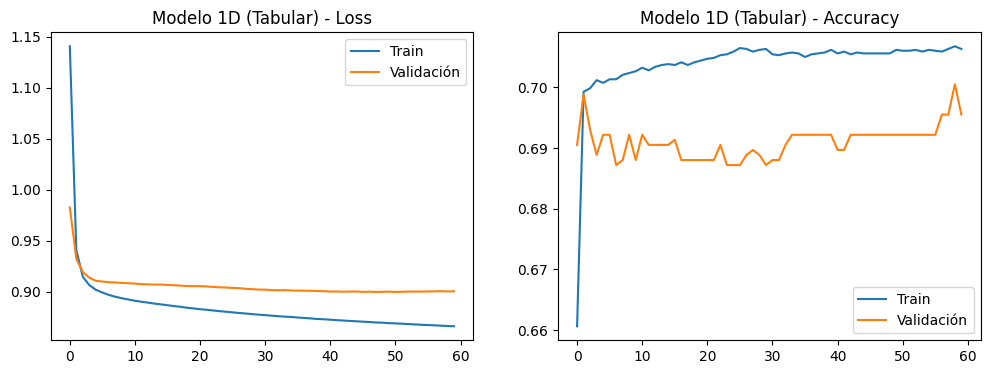

In [53]:
#Grafica para comportamiento
class_names = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
def plot_training(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'{model_name} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.show()

plot_training(model_1d_fit, 'Modelo 1D (Tabular)')

In [54]:
acc_1d = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred_1d, axis=1))
print(classification_report(
    np.argmax(y_test, axis=1),
    np.argmax(y_pred_1d, axis=1),
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.40      0.03      0.06        65
         bcc       0.50      0.01      0.02       103
         bkl       0.36      0.44      0.40       220
          df       0.00      0.00      0.00        23
          nv       0.77      0.95      0.85      1341
        vasc       0.00      0.00      0.00        28
         mel       0.30      0.09      0.14       223

    accuracy                           0.70      2003
   macro avg       0.33      0.22      0.21      2003
weighted avg       0.63      0.70      0.63      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:
#El modelo parece estar prediciendo más la clase nv por su alta frecuencia
#La clase df y vasc son practicamente olvidadas, lo que significa que el modelo las ignora
#Se observa que el modelo tabular tiene limitaciones
#El modelo entraga un accuracy de 70% pero aprende a predecir casi siempre la clase nv. Sin importar como se modifiquen los hiper-parametros la clase nv sera más presente limitando el accuracy
#Se necesitarian más datos para distinguir el tipo de cancer de piel

In [56]:
# MODELO 2D IMAGENES

In [57]:
#Hipermetros
lr_2d         = 0.001
n_epochs_2d   = 20
# Con 40 épocas se observó overfitting desde la época 20,
# se redujo a 20 para quedarse en el punto óptimo de validación
batch_size_2d = 64
# Batch de 128 generó más overfitting, 64 da mejor generalización

In [58]:
#modelo
model_2d = Sequential([
    Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 3), name="conv1"),
    MaxPooling2D((2, 2), name="pool1"),

    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 3), name="conv2"),
    # Se duplican los filtros en la segunda capa para capturar patrones más complejos
    MaxPooling2D((2, 2), name="pool2"),

    Flatten(name='flatten'),

    Dense(64, activation='relu', name='dense'),
    # capa densa reducida (vs 128 original) para evitar overfitting en imágenes
    Dropout(0.3, name='dropout'),
    # regularización leve para reducir la brecha entre train y validación
    Dense(7, activation='softmax', name='output_2d')

], name = "modelo_2d")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model_2d.summary()

Model: "modelo_2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_2d (Dense)               │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,807 (221.90 KB)

 Trainable params: 56,807 (221.90 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# Compilación del modelo
optimizer_2d = Adam(learning_rate=lr_2d)

In [61]:
model_2d.compile(optimizer=optimizer_2d, loss = "categorical_crossentropy", metrics=["accuracy"])

In [62]:
model_2d_fit = model_2d.fit(X_img_train, y_train, validation_data = (X_img_val, y_val), epochs = n_epochs_2d, batch_size = batch_size_2d)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6623 - loss: 1.1529 - val_accuracy: 0.6697 - val_loss: 0.9843
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6743 - loss: 0.9676 - val_accuracy: 0.6730 - val_loss: 0.9190
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6811 - loss: 0.9257 - val_accuracy: 0.6814 - val_loss: 0.8867
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.6899 - loss: 0.8978 - val_accuracy: 0.6814 - val_loss: 0.8691
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6902 - loss: 0.8779 - val_accuracy: 0.6822 - val_loss: 0.8421
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6925 - loss: 0.8561 - val_accuracy: 0.6905 - val_loss: 0.8271
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6996 - loss: 0.8459 - val_accuracy: 0.6930 - val_loss: 0.8126
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6977 - loss: 0.8255 - val_accu

In [63]:
y_pred_2d = model_2d.predict(X_img_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


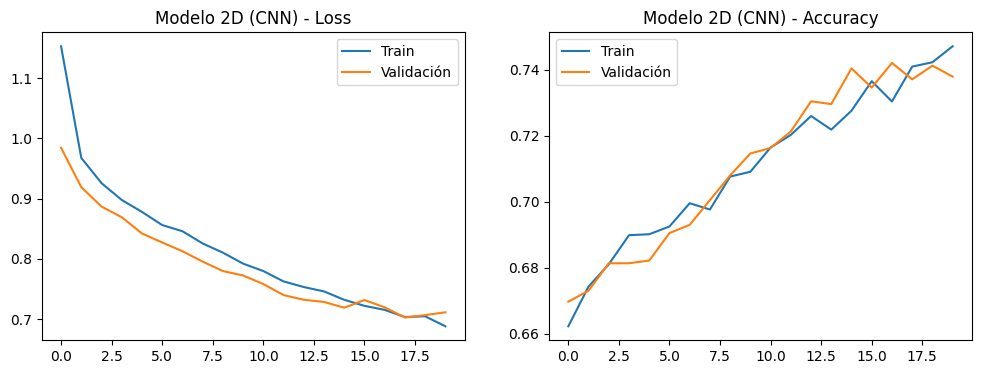

In [64]:
#Grafica para comportamiento
class_names = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
def plot_training(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'{model_name} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.show()

plot_training(model_2d_fit, 'Modelo 2D (CNN)')

In [65]:
acc_2d = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred_2d, axis=1))
print(classification_report(
    np.argmax(y_test, axis=1),
    np.argmax(y_pred_2d, axis=1),
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.50      0.08      0.13        65
         bcc       0.51      0.47      0.49       103
         bkl       0.50      0.26      0.35       220
          df       0.00      0.00      0.00        23
          nv       0.77      0.96      0.86      1341
        vasc       0.75      0.54      0.62        28
         mel       0.47      0.22      0.30       223

    accuracy                           0.73      2003
   macro avg       0.50      0.36      0.39      2003
weighted avg       0.68      0.73      0.68      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


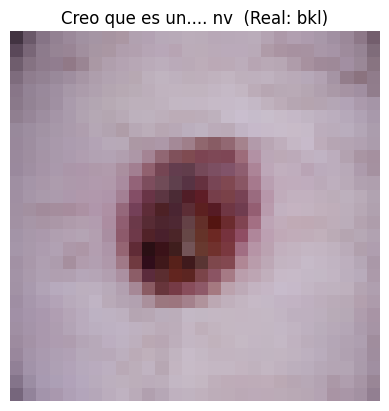

In [66]:
#Revision de las predicciones
idx = 34
plt.imshow(X_img_test[idx])
plt.axis("off")
prediction = class_names[np.argmax(y_pred_2d[idx])]
real = class_names[np.argmax(y_test[idx])]
plt.title(f"Creo que es un.... {prediction}  (Real: {real})")
plt.show()

In [67]:
# El modelo mejora respecto al modelo 1D tabular, la clase bcc y vasc ahora tienen
# un reconocimiento de 52% y 46% respectivamente, mejorando del 0% del anterior modelo
# sin embargo, akiec con un 8% casu nunca es detectado. El desbalanceo de clases
# sigue siendo el principal limite. Las clases con pocas muestras como df, akiec
# serán más dificiles de detectar. Pero sigue siendo un modelo mejorado a comparación
# del modelo 1D

In [68]:
# ESTRATEGIA LATE-FUSION

In [69]:
# Hiperparametros
lr_late         = 0.001
# Con learning rate mayor a 0.001 el modelo empieza a presentar overfitting con
# mayor frecuencia
n_epochs_late   = 40
# Con 40 se evidencia el mejor comportamiento para evitar overfitting
batch_size_late = 64

In [70]:
def build_late_fusion_model():
    # Define los inputs para cada modalidad
    tabular_input = Input(shape=(X_tab_train.shape[1],), name="tabular_input")
    vision_input  = Input(shape=(28, 28, 3), name="vision_input")

    # Obtiene las predicciones finales de cada modelo ya entrenado
    tabular_pred = model_1d(tabular_input)
    vision_pred  = model_2d(vision_input)

    # Fusión: concatenamos las probabilidades (7 + 7 = 14 valores)
    merged = Concatenate()([tabular_pred, vision_pred])
    output = Dense(7, activation="softmax", name="output_late")(merged)

    late_fusion_model = Model(
        inputs=[tabular_input, vision_input],
        outputs=output,
        name="modelo_late_fusion"
    )
    return late_fusion_model

In [71]:
model_late = build_late_fusion_model()

In [72]:
model_late.summary()

Model: "modelo_late_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vision_input        │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ modelo_1d           │ (None, 7)         │     19,975 │ tabular_input[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ modelo_2d           │ (None, 7)         │     56,807 │ vision_input[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14)        │          0 │ modelo_1d[0][0],  │
│ (Concatenate)       │                   │            │ modelo_2d[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_late (Dense) │ (None, 7)         │        105 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 76,887 (300.34 KB)

 Trainable params: 76,887 (300.34 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
optimizer_late = Adam(learning_rate=lr_late)

In [74]:
model_late.compile(optimizer=optimizer_late, loss="categorical_crossentropy", metrics=["accuracy"])

In [75]:
model_3_fit = model_late.fit([X_tab_train, X_img_train], y_train, validation_data = ([X_tab_val, X_img_val], y_val), epochs = n_epochs_late, batch_size = batch_size_late)

Epoch 1/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.5897 - loss: 1.6439 - val_accuracy: 0.6697 - val_loss: 1.4366
Epoch 2/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6695 - loss: 1.3368 - val_accuracy: 0.6697 - val_loss: 1.2590
Epoch 3/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6695 - loss: 1.2007 - val_accuracy: 0.6697 - val_loss: 1.1576
Epoch 4/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.6695 - loss: 1.1193 - val_accuracy: 0.6697 - val_loss: 1.0945
Epoch 5/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.6695 - loss: 1.0666 - val_accuracy: 0.6697 - val_loss: 1.0577
Epoch 6/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6693 - loss: 1.0336 - val_accuracy: 0.6697 - val_loss: 1.0305
Epoch 7/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.6696 - loss: 1.0104 - val_accuracy: 0.6697 - val_loss: 1.0076
Epoch 8/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6695 - loss: 0.9928 - val_accu

In [76]:
y_pred_late = model_late.predict([X_tab_test, X_img_test])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


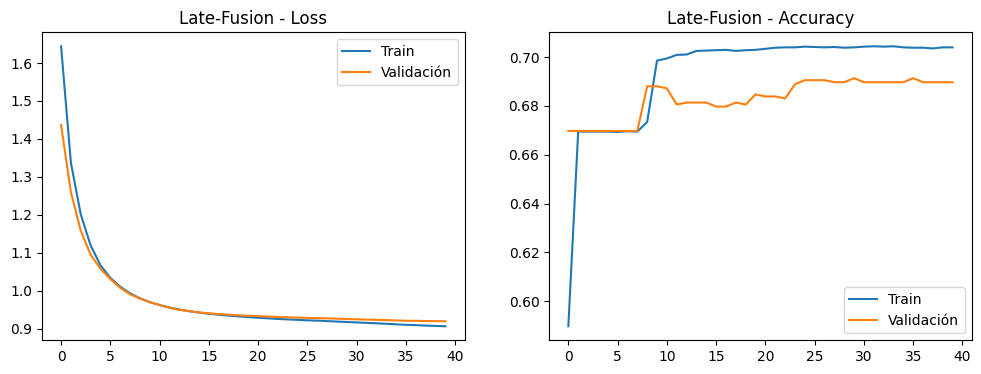

In [77]:
#Grafica para comportamiento
class_names = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
def plot_training(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'{model_name} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.show()

plot_training(model_3_fit, 'Late-Fusion')

In [78]:
acc_late = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred_late, axis=1))
print(classification_report(
    np.argmax(y_test, axis=1),
    np.argmax(y_pred_late, axis=1),
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        65
         bcc       0.00      0.00      0.00       103
         bkl       0.37      0.45      0.40       220
          df       0.00      0.00      0.00        23
          nv       0.75      0.97      0.84      1341
        vasc       0.00      0.00      0.00        28
         mel       0.00      0.00      0.00       223

    accuracy                           0.70      2003
   macro avg       0.16      0.20      0.18      2003
weighted avg       0.54      0.70      0.61      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


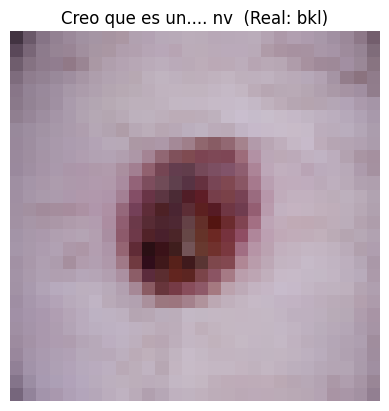

In [79]:
idx = 34
plt.imshow(X_img_test[idx])
plt.axis("off")
prediction = class_names[np.argmax(y_pred_late[idx])]
real = class_names[np.argmax(y_test[idx])]
plt.title(f"Creo que es un.... {prediction}  (Real: {real})")
plt.show()

In [80]:
# Con el comportamiento del plot, a pesar que el modelo no genera overfitting,
# con la Late-fusion y dado que tanto el modelo 1D como el modelo 2D ya
# presentaban limitaciones o sesgos hacia la clase nv por el desbalanceo del dataset,
# la fusión parece que se complementen de cierta menera. El accuracy en varias prubas converge
# a 70%, sin embargo refleja que el modelo aun ignora vasc
# mostrando nv y bkl con mayor frecuencia

In [80]:
# La razón por la que la late-fusion no mejora mucho es que tanto model_1d como
# model_2d ya estaban sesgados hacia la clase nv. La late-fusion combina las
# dos probabilidades finales de ambos modelos, pero esas probabilidades ya presentan
# el mismo sesgo, así que el clasificador de fusión hereda el mismo problema.

In [81]:
# EARLY-FUSION

In [82]:
# Hiperparámetros
lr_early         = 0.002
n_epochs_early   = 10
batch_size_early = 64

In [83]:
# Se definen los inputs de cada modalidad
def build_early_fusion_model():
    tabular_input = Input(shape=(X_tab_train.shape[1],), name="tabular_input")
    vision_input  = Input(shape=(28, 28, 3), name="vision_input")

    # Extracción de características del modelo 1D (hasta dense_2)
    x1 = model_1d.get_layer('dense_1')(tabular_input)
    tabular_features = model_1d.get_layer('dense_2')(x1)

    # Extracción de características del modelo 2D
    x2 = vision_input
    for layer_name in ['conv1', 'pool1', 'conv2', 'pool2', 'flatten', 'dense']:
        x2 = model_2d.get_layer(layer_name)(x2)
    vision_features = x2

    # Fusión: concatenamos las representaciones internas
    merged = Concatenate()([tabular_features, vision_features])

    # Clasificador más profundo que en late-fusion
    x = Dense(64, activation="relu", name="dense_early_1")(merged)
    x = Dropout(0.5, name="dropout_early")(x)
    #x = Dense(64,  activation="relu", name="dense_early_2")(x)
    output = Dense(7, activation="softmax", name="output_early")(x)

    early_fusion_model = Model(
        inputs=[tabular_input, vision_input],
        outputs=output,
        name="modelo_early_fusion"
    )
    return early_fusion_model

In [84]:
model_early = build_early_fusion_model()

In [85]:
model_early.summary()

Model: "modelo_early_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vision_input        │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 26, 26,    │        448 │ vision_input[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 13, 13,    │          0 │ conv1[1][0]       │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 11, 11,    │      4,640 │ pool1[1][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 5, 5, 32)  │          0 │ conv2[1][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,560 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 800)       │          0 │ pool2[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     51,264 │ flatten[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ dense_2[1][0],    │
│ (Concatenate)       │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_early_1       │ (None, 64)        │     12,352 │ concatenate_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_early       │ (None, 64)        │          0 │ dense_early_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_early        │ (None, 7)         │        455 │ dropout_early[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 88,231 (344.65 KB)

 Trainable params: 88,231 (344.65 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
optimizer_4 = Adam(learning_rate=lr_early)

In [87]:
model_early.compile(optimizer=optimizer_4, loss="categorical_crossentropy", metrics=["accuracy"])

In [88]:
model_4_fit =model_early.fit([X_tab_train, X_img_train], y_train, validation_data=([X_tab_val, X_img_val], y_val), epochs=n_epochs_early, batch_size=batch_size_early)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6520 - loss: 1.3614 - val_accuracy: 0.7088 - val_loss: 0.7785
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7294 - loss: 0.7738 - val_accuracy: 0.7479 - val_loss: 0.7021
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7461 - loss: 0.7091 - val_accuracy: 0.7496 - val_loss: 0.6813
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.7505 - loss: 0.6860 - val_accuracy: 0.7687 - val_loss: 0.6346
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.7570 - loss: 0.6597 - val_accuracy: 0.7629 - val_loss: 0.6370
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7615 - loss: 0.6426 - val_accuracy: 0.7621 - val_loss: 0.6424
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7703 - loss: 0.6294 - val_accuracy: 0.7637 - val_loss: 0.6420
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7752 - loss: 0.6157 - val_accu

In [89]:
y_pred_early = model_early.predict([X_tab_test, X_img_test])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


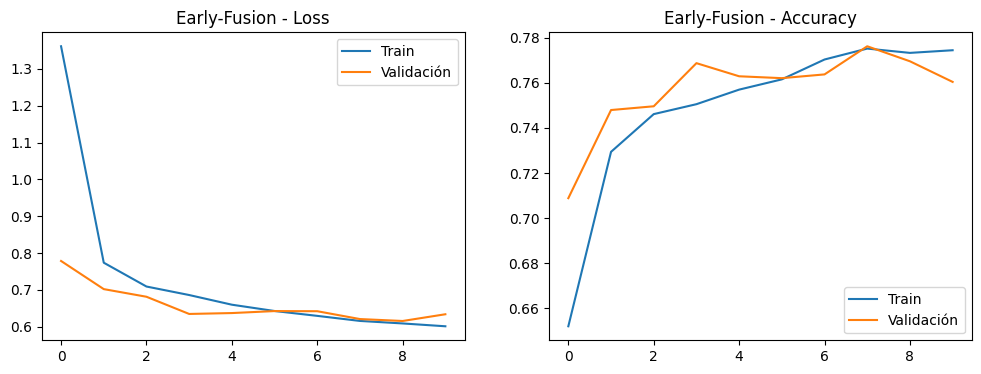

In [90]:
#Grafica para comportamiento
class_names = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc', 'mel']
def plot_training(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'{model_name} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.show()

plot_training(model_4_fit, 'Early-Fusion')

In [91]:
acc_early = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred_early, axis=1))
print(f"Accuracy en Test: {acc_early:.4f} ({acc_early*100:.2f}%)")
print(classification_report(
    np.argmax(y_test, axis=1),
    np.argmax(y_pred_early, axis=1),
    target_names=class_names
))

Accuracy en Test: 0.7639 (76.39%)
              precision    recall  f1-score   support

       akiec       0.35      0.14      0.20        65
         bcc       0.58      0.48      0.52       103
         bkl       0.48      0.56      0.52       220
          df       0.43      0.26      0.32        23
          nv       0.89      0.91      0.90      1341
        vasc       0.78      0.64      0.71        28
         mel       0.47      0.50      0.48       223

    accuracy                           0.76      2003
   macro avg       0.57      0.50      0.52      2003
weighted avg       0.76      0.76      0.76      2003



In [92]:
# Early fusion alcanza un accuracy de 77% que supera a los otrso 3 modelos
# Sin embargo la gráfica un poco de mayor muestra overfitting en el traning loss, pero el val_accuaracy
# se mantiene estable lo que hace pensar que el modelo pudo alcanzar un limite
# en lo que puede aprender de los dos datasets

# Un punto notorio, es que ya la gran mayoria de clases tiene presencia de ser detectado
# por el modelo ya que el recall esta indicando que el modelo va a ser prediciendo
# todas las clases, sin embargo tendra mayor tendencia hacia la clase nv por el mismo
# punto asociado al desbalanceo del dataset